# Spatial plots
Like in the E3SMv3 overview paper

Time-averaged ERFaci and ∆lnLWP for 
* default
* ensemble mean
* "strongest" 5% (most + for ∆lnLWP, most - for ERFaci)
* "weakest" 5% too

**revised version** 
  

In [38]:
import pickle

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import tol_colors as tc
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib as mpl

from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec


In [39]:
main_path = "/glade/u/home/jnug/work/multi_PPE_data/"
file_path = main_path + "annual_means/"
save_dir = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/figures/"
pickle_path = main_path + "pickle_jar/"


In [40]:
ds_e3sm = xr.open_dataset(file_path + "E3SMv3_data_regrid1x1.nc")
ds_ga71 = xr.open_dataset(file_path + "GA7.1_data_time_avg.nc")
ds_cam6 = xr.open_dataset(file_path + "CAM6_data_time_avg.nc") 
ds_eham = xr.open_dataset(file_path + "ECHAM6-HAM_data_time_avg.nc") 

# make a PPE dataset dictionary
ds_dict = {"EAMv3": ds_e3sm, "UKESM1-GA7.1": ds_ga71, "CAM6": ds_cam6, "ECHAM6-HAM": ds_eham}


Function from the overview paper scripts

In [6]:
def get_top_bottom_5(da_xyavg, da_rg, print_low_stats=False):
    """ 
    Return average of da_rg for the ensemble members whose mean values are
    <=5th pctl or >=95th pctl.
    """
    low = da_xyavg.where(da_xyavg <= da_xyavg.quantile(.05), drop=True).member
    high = da_xyavg.where(da_xyavg >= da_xyavg.quantile(.95), drop=True).member
    da_low = da_rg.sel(member=low).mean(dim="member")
    da_high = da_rg.sel(member=high).mean(dim="member")

    if print_low_stats:
        print("mean: {}, min: {}, max: {}".format(da_low.mean().values, da_low.min().values, da_low.max().values))

    return da_low, da_high


In [7]:
def plot_globe(ax, da, vmin=-0.01, vmax=0.01, cmap="seismic", transform=None, 
               lognorm=False, linthresh=1e-2, norm=None):
    """ Plot a single globe (aka time average for one group)
    """
    if lognorm:
        pcm = ax.pcolormesh(da.lon, da.lat, da, cmap=cmap, transform=transform,
                           norm=mcolors.SymLogNorm(vmin=vmin, vmax=vmax, linthresh=linthresh))
    if not lognorm and norm is not None:
        pcm = ax.pcolormesh(da.lon, da.lat, da, cmap=cmap, transform=transform, norm=norm)
    else:
        pcm = ax.pcolormesh(da.lon, da.lat, da, cmap=cmap, vmin=vmin, vmax=vmax, transform=transform)
    
    return pcm



In [20]:
# https://stackoverflow.com/questions/55665167/asymmetric-color-bar-with-fair-diverging-color-map
class MidpointNormalize(mcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        mcolors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        v_ext = np.max( [ np.abs(self.vmin), np.abs(self.vmax) ] )
        x, y = [-v_ext, self.midpoint, v_ext], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))
        

In [28]:
def plot_var(ppe, ax_df, ax_mean, ax_low, ax_high, da_rg, vmin, vmax, coastlines=True, return_pcm=True,
            transform=ccrs.PlateCarree(), return_stats=False, varname=None, annotate_mean=True,
            norm=None, fsize=13, cmap="seismic"):
    """ 
    Given some data array, plot a global/time mean of the
    default member and averages of the lowest & highest 5%
    """
    # get the default
    if ppe == "CAM6":
        da_df = da_rg.sel(member="000")
    else:
        da_df = da_rg.sel(member=0)

    # get the mean
    da_mean = da_rg.mean(dim="member")

    # get the top & bottom 5%
    weights = np.cos(np.deg2rad(da_rg.lat))
    da_xyavg = da_rg.weighted(weights).mean(dim=["lat", "lon"])
    if varname.lower() == "delta_nd":
        print_low_stats = True
    else:
        print_low_stats = False
    da_low, da_high = get_top_bottom_5(da_xyavg, da_rg, print_low_stats=print_low_stats)

    
    # plot variables
    pcm = plot_globe(ax_df, da_df, vmin=vmin, vmax=vmax, transform=transform, norm=norm, cmap=cmap) 
    pcm = plot_globe(ax_mean, da_mean, vmin=vmin, vmax=vmax, transform=transform, norm=norm, cmap=cmap)

    # ERFaci "lowest" is actually the "strongest" (most negative)
    if varname == "ERFaci": 
        pcm = plot_globe(ax_low, da_high, vmin=vmin, vmax=vmax, transform=transform, norm=norm, cmap=cmap) 
        pcm = plot_globe(ax_high, da_low, vmin=vmin, vmax=vmax, transform=transform, norm=norm, cmap=cmap) 
    else:
        pcm = plot_globe(ax_low, da_low, vmin=vmin, vmax=vmax, transform=transform, norm=norm, cmap=cmap) 
        pcm = plot_globe(ax_high, da_high, vmin=vmin, vmax=vmax, transform=transform, norm=norm, cmap=cmap) 

    if coastlines:
        ax_df.coastlines()
        ax_mean.coastlines()
        ax_low.coastlines()
        ax_high.coastlines()


    # spatial means (to annotate)
    if annotate_mean:
        da_xyavg_low = da_low.weighted(weights).mean(dim=["lat", "lon"])
        da_xyavg_high = da_high.weighted(weights).mean(dim=["lat", "lon"])
        da_xyavg_df = da_df.weighted(weights).mean(dim=["lat", "lon"])
        da_xyavg_mean = da_mean.weighted(weights).mean(dim=["lat", "lon"])

        if varname == "ERFaci":
            ax_xyavg_dict = {ax_low: da_xyavg_high, ax_high: da_xyavg_low, ax_df: da_xyavg_df, ax_mean: da_xyavg_mean}
        else:
            ax_xyavg_dict = {ax_low: da_xyavg_low, ax_high: da_xyavg_high, ax_df: da_xyavg_df, ax_mean: da_xyavg_mean}
        for ax, xyavg in ax_xyavg_dict.items():
            ax.set_title(f"{xyavg:.2f}", fontsize=fsize)
    
    if return_stats: 
        print("{} low mean: {:.4f}, max: {:.4f}, min: {:.4f}".format(varname, da_low.mean(), da_low.max(), da_low.min()))

    if return_pcm:
        return pcm



In [29]:
# https://stackoverflow.com/questions/55665167/asymmetric-color-bar-with-fair-diverging-color-map
class MidpointNormalize(mpl.colors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        mpl.colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        v_ext = np.max( [ np.abs(self.vmin), np.abs(self.vmax) ] )
        x, y = [-v_ext, self.midpoint, v_ext], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))


In [31]:
def plot_spatial_means(da_rg_dict, varname, vmin, vmax, units, figsize=(16, 9), tsize=20, fsize=14, 
                       labsize=13, save=False, midpoint_norm=False, fake_pcm=None, cmap="seismic", 
                      norm=None):
    """
    """
    n_ppes = len(list(da_rg_dict.keys()))
    col_lab_list = ["Default", "Ensemble\nMean", "Weakest\n5%", "Strongest\n5%"]

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(n_ppes+1, 6, width_ratios=[0.4, 1, 1, 1, 1, 0.1],
                  height_ratios=[0.1, *[1]*n_ppes], hspace=0.2)
    proj = ccrs.Mollweide()

    if norm is not None and midpoint_norm:
        norm = MidpointNormalize(vmin=vmin, vmax=vmax, midpoint=0)
    elif norm is None:
        norm = None
    
    # loop through columns to label
    for i in range(len(col_lab_list)):
        # label
        ax_lab = plt.subplot(gs[i+1, 0])
        ax_lab.axis("off")
        ax_lab.annotate(col_lab_list[i], xy=(0.5, 0.5), xycoords='axes fraction',
                        verticalalignment="center", horizontalalignment="center", 
                       fontsize=tsize)

    # --- loop through PPEs & plot ---
    for i, ppe in enumerate(list(da_rg_dict.keys())):
        # plot data
        ax_df = plt.subplot(gs[1, i+1], projection=proj)
        ax_mean = plt.subplot(gs[2, i+1], projection=proj)
        ax_low = plt.subplot(gs[3, i+1], projection=proj)
        ax_high = plt.subplot(gs[4, i+1], projection=proj)
        var_dict = da_rg_dict[ppe]
        pcm = plot_var(ppe, ax_df, ax_mean, ax_low, ax_high, var_dict[varname], vmin, vmax, 
                       varname=varname, norm=norm, cmap=cmap)

        # label the row
        ax_hlab = plt.subplot(gs[0, i+1])
        ax_hlab.axis("off")
        ax_hlab.annotate(ppe, xy=(0.5, 0.5), xycoords='axes fraction',
                        verticalalignment="center", horizontalalignment="center",
                        fontsize=tsize)

        # colorbar
        ax_cb = plt.subplot(gs[i+1, -1])
        ax_cb.axis("off")
        ax_ins = inset_axes(ax_cb, width="80%", height="100%", loc="center left")
        if midpoint_norm:
            cbar = plt.colorbar(fake_pcm, cax=ax_ins, orientation="vertical", extend="both")#, fraction=0.046, pad=0.04)
        else:
            cbar = plt.colorbar(pcm, cax=ax_ins, orientation="vertical", extend="both")#, fraction=0.046, pad=0.04)
        varlab = varname.replace("delta_", r"$\Delta$")
        cbar.set_label(f"{varlab} [{units}]", fontsize=fsize)
        cbar.ax.tick_params(labelsize=labsize)
    
    # save
    if save:
        plt.savefig(save_dir + f"spatial_maps_{varname}_dmws.png", dpi=300, bbox_inches="tight")
    
    plt.show()


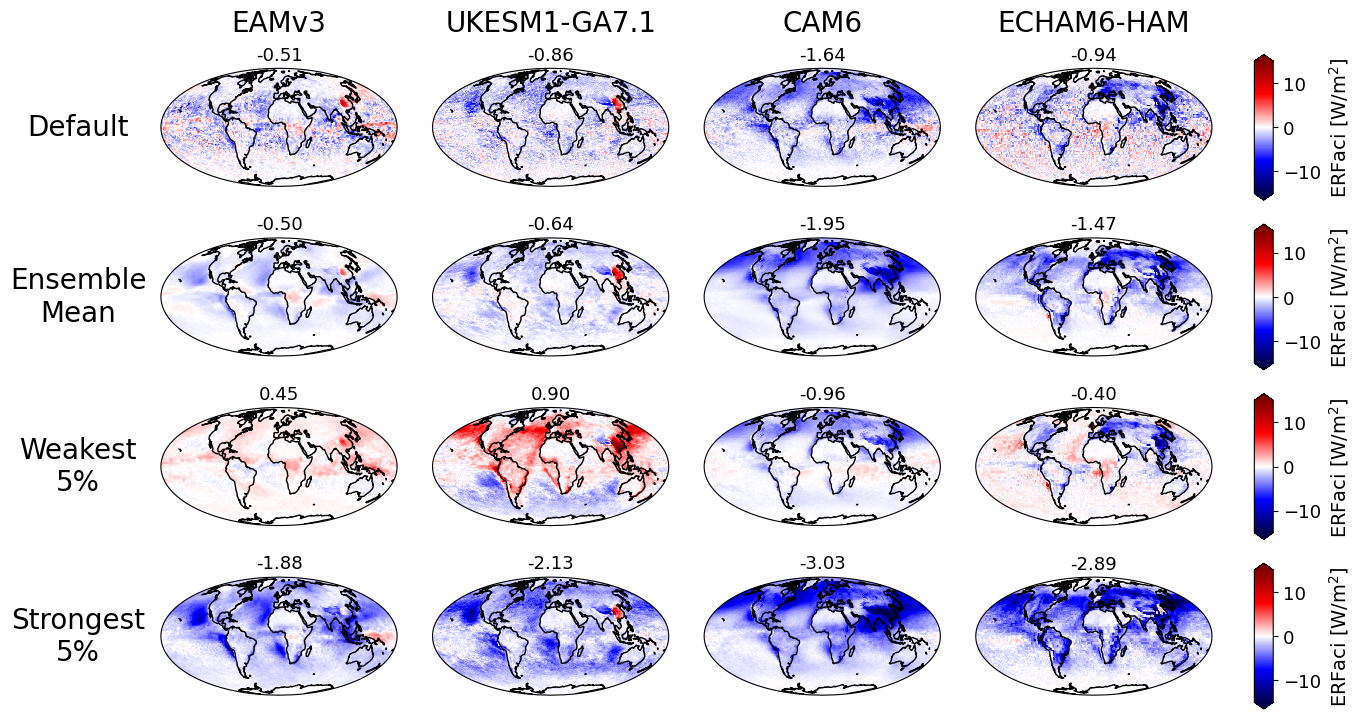

In [32]:
plot_spatial_means(ds_dict, "ERFaci", vmin=-15, vmax=15, units="W/m$^2$", save=True)


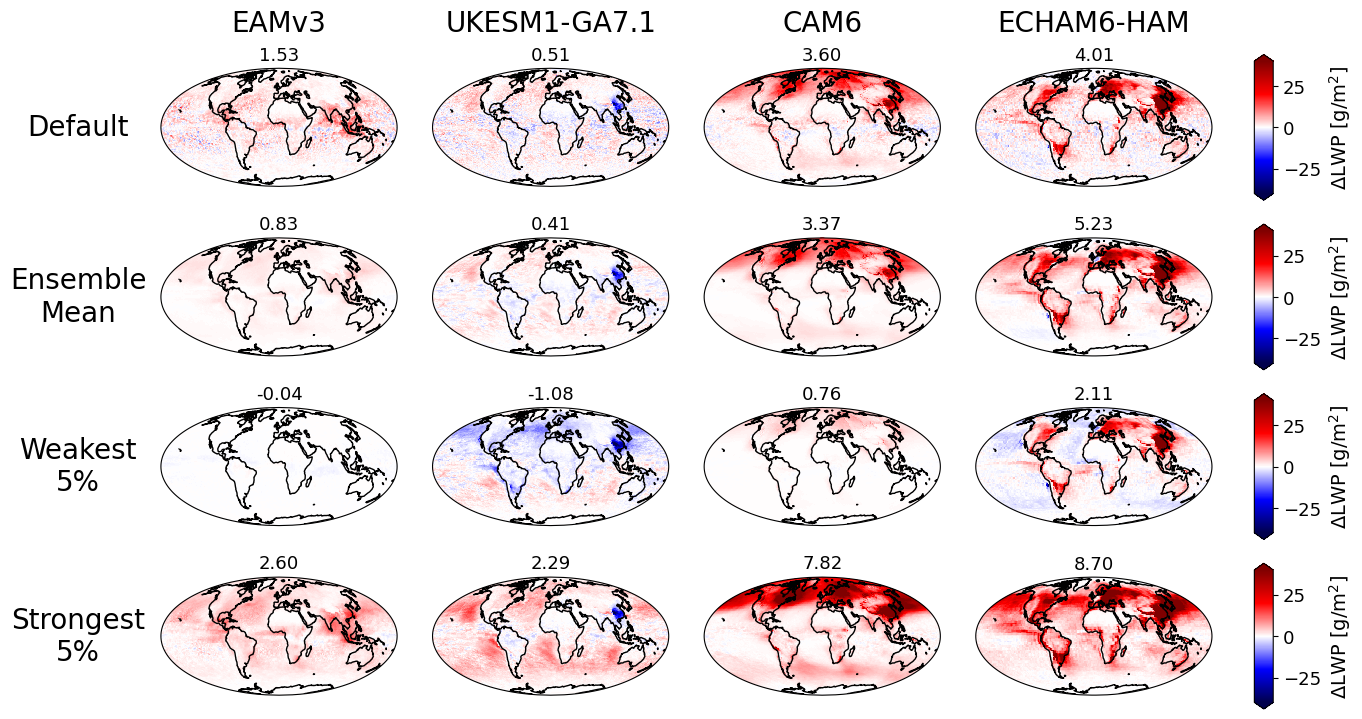

In [15]:
plot_spatial_means(ds_dict, "delta_LWP", vmin=-40, vmax=40, units="g/m$^2$", save=True)


mean: 0.5767479538917542, min: -34.70035934448242, max: 54.371952056884766
mean: 9.58829402923584, min: -357.37689208984375, max: 516.3622436523438
mean: 4.372806549072266, min: -6.797089099884033, max: 67.59683990478516
mean: 6.754550933837891, min: -113.72978210449219, max: 379.2236633300781


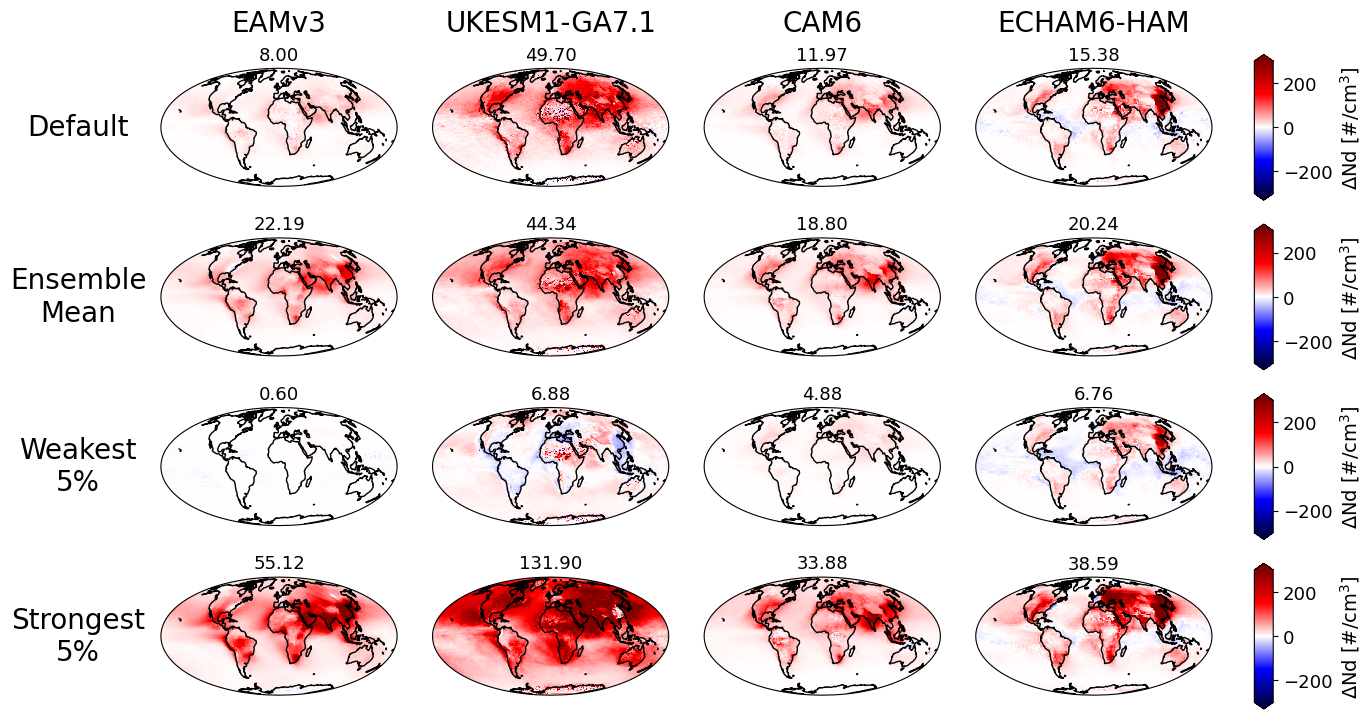

In [26]:
plot_spatial_means(ds_dict, "delta_Nd", vmin=-300, vmax=300, units="#/cm$^3$", save=True)
